
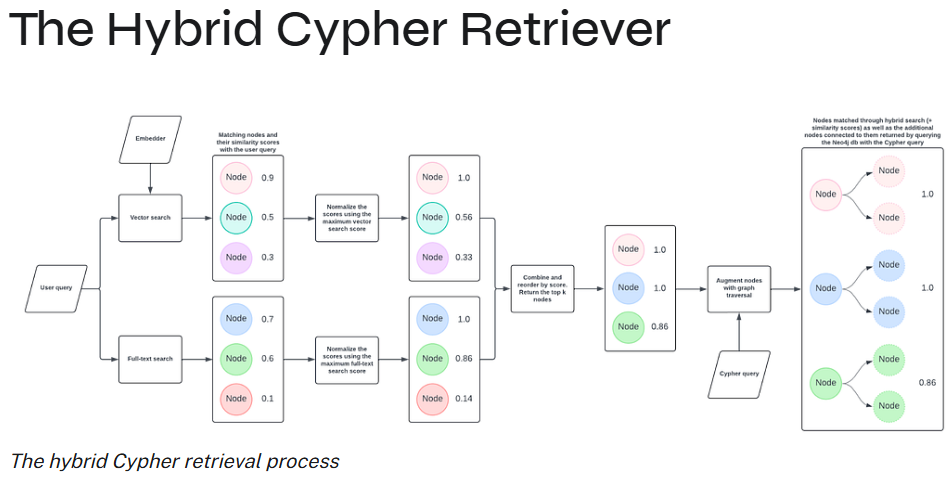


The HybridCypherRetriever enhances the hybrid search process by adding a graph traversal step. It begins by identifying an initial set of nodes through a combined search over vector and full-text indexes, then uses a specified Cypher query to retrieve additional information from the graph for each of these nodes.

To make use of this retriever, we first need to write a Cypher query to specify exactly what additional information to fetch along with each of the nodes retrieved through hybrid search. Given we are looking to answer questions about actors in movies, we can use the following query:

### Preamble

**NOTE: The APOC core library must be installed in your Neo4j instance ([Installation](https://neo4j.com/docs/apoc/current/installation/))**

In [ ]:
%pip install -e ..

In [17]:
from ragsphere import RAG
from ragsphere.models import Text2CypherRetrieverConfig
from ragsphere.graphrag import Text2CypherRetriever

### Indexing Configuration

In [26]:
# Default configuration
indexer = HybridGRIndexer()

In [27]:
indexer_config_dict = {
    "similarity_fn": "cosine", 
    "f_index_name": "ft_index_all",
    "v_index_name": "vector_index_all",
    "target_nodes": None,
    "property_limit": 40
}
indexer_config_class = HybridGRIndexerConfig(**indexer_config_dict)

indexer_with_dict = HybridGRIndexer(indexer_config_dict) # parameter=indexer_config_dict
indexer_with_class = HybridGRIndexer(config=indexer_config_class)

In [28]:
print(indexer_config_class)
print(indexer_with_dict.config)
print(indexer_with_class.config)

HybridGRIndexerConfig(similarity_fn='cosine', f_index_name='ft_index_all', v_index_name='vector_index_all', target_nodes=None, property_limit=40)
HybridGRIndexerConfig(similarity_fn='cosine', f_index_name='ft_index_all', v_index_name='vector_index_all', target_nodes=None, property_limit=40)
HybridGRIndexerConfig(similarity_fn='cosine', f_index_name='ft_index_all', v_index_name='vector_index_all', target_nodes=None, property_limit=40)


### Retrieval Configuration

In [14]:
# Default configuration
retriever = HybridCypherGRRetriever()

In [15]:
retriever_config_dict = {
    "similarity_fn": "cosine", 
    "f_index_name": "ft_index_all",
    "v_index_name": "vector_index_all",
    "top_k": 5,
}
retriever_config_class = HybridCypherGRRetrieverConfig(**retriever_config_dict)

retriever_with_dict = HybridGRRetriever(retriever_config_dict) # parameter=retriever_config_dict
retriever_with_class = HybridGRRetriever(config=retriever_config_class)

In [16]:
print(retriever_config_class)
print(retriever_with_dict.config)
print(retriever_with_class.config)

HybridCypherGRRetrieverConfig(top_k=5, similarity_fn='cosine', f_index_name='ft_index_all', v_index_name='vector_index_all')
HybridGRRetrieverConfig(top_k=5, similarity_fn='cosine', f_index_name='ft_index_all', v_index_name='vector_index_all', return_properties=None)
HybridCypherGRRetrieverConfig(top_k=5, similarity_fn='cosine', f_index_name='ft_index_all', v_index_name='vector_index_all')


### Instantiation

**Default**

In [11]:
rag = RAG(
    indexer = "graphrag",
    retriever = "graphrag", 
    verbosity=1
)

2025-10-01 23:27:09,994 - INFO - RAG initialized with verbosity 1
2025-10-01 23:27:10,013 - INFO - The indexing technique is set to: 'graphrag'

2025-10-01 23:27:10,014 - INFO - The retrieval technique is set to: 'graphrag'

2025-10-01 23:27:10,016 - INFO - The document path has not been specified.
2025-10-01 23:27:10,017 - INFO - Using default path: '../db/data'

2025-10-01 23:27:10,018 - INFO - The graph database has not been specified.
2025-10-01 23:27:10,020 - INFO - Using default graph database: 'Neo4j'

2025-10-01 23:27:10,020 - INFO - The vector database has not been specified.
2025-10-01 23:27:10,020 - INFO - Using default vector database: 'Neo4j'

2025-10-01 23:27:10,020 - INFO - The indexing LLM has not been specified.
2025-10-01 23:27:10,026 - INFO - Using the default indexing LLM: 'llama3.3:latest'

2025-10-01 23:27:10,026 - INFO - The query LLM has not been specified.
2025-10-01 23:27:10,029 - INFO - Using the default query LLM: 'llama3.3:latest'

2025-10-01 23:27:10,030 -

**Custom Option 1**

In [32]:
# Vector GraphRAG
rag = RAG(
    indexer = "vectorgraphrag", 
    indexer_config = indexer_config_dict, 
    retriever = "vectorgraphrag", 
    retriever_config = retriever_config_dict,
    verbosity=1
)

2026-02-09 15:01:06,061 - INFO - RAG initialized with verbosity 1
2026-02-09 15:01:06,064 - INFO - The indexing technique is set to: 'vectorgraphrag'

2026-02-09 15:01:06,065 - INFO - The retrieval technique is set to: 'vectorgraphrag'

2026-02-09 15:01:06,066 - INFO - The document path has not been specified.
2026-02-09 15:01:06,067 - INFO - Using default path: '../db/data'

2026-02-09 15:01:06,068 - INFO - The graph database has not been specified.
2026-02-09 15:01:06,069 - INFO - Using default graph database: 'Neo4j'

2026-02-09 15:01:06,070 - INFO - The vector database has not been specified.
2026-02-09 15:01:06,071 - INFO - Using default vector database: 'Neo4j'

2026-02-09 15:01:06,072 - INFO - The indexing LLM has not been specified.
2026-02-09 15:01:06,073 - INFO - Using the default indexing LLM: 'gpt-oss:120b'

2026-02-09 15:01:06,073 - INFO - The query LLM has not been specified.
2026-02-09 15:01:06,074 - INFO - Using the default query LLM: 'gpt-oss:120b'

2026-02-09 15:01:06

TypeError: VectorGRRetrieverConfig.__init__() got an unexpected keyword argument 'examples'

### Indexing

In [26]:
# Indexing for hybridgaphrag
rag.index(verbosity=1)

2026-02-09 14:00:01,095 - WARNING - No indexing technique has been specified.


### Retrieval

In [27]:
query_text = "List all anomaly report IDs"
#query_text = "What is the structure of the anomaly reports?"
retrieval_query = "MATCH (a:AnomalyReport) RETURN a.reportId"

response = rag.query(
    prompt=query_text, 
    #retrieval_query=retrieval_query, 
    verbosity=1
)

2026-02-09 14:01:07,278 - INFO - DOING 'text2cypher' RETRIEVAL WITH Text2CypherRetrieverConfig(top_k=0, examples=["USER INPUT: 'Which actors starred in the Matrix?' QUERY: MATCH (p:Person)-[:ACTED_IN]->(m:Movie) WHERE m.title = 'The Matrix' RETURN p.name"])
2026-02-09 14:01:07,279 - INFO - USING THE FOLLOWING QUERY: 'List all anomaly report IDs'


Connection successful: True
{"temperature": 0}


2026-02-09 14:01:18,723 - INFO - HTTP Request: POST http://sc-030362l.intra.dlr.de:11434/api/chat "HTTP/1.1 200 OK"


In [8]:
response["answer"]

'The anomaly reports are stored as JSON‑style dictionaries that follow a fairly regular schema.  \nAlthough a few fields appear only on certain reports (e.g., the older EPDS/ECLSS entries), the bulk of the reports share the same logical sections:\n\n| **Section** | **Typical Keys** | **What the key holds** |\n|-------------|------------------|------------------------|\n| **Identification / Metadata** | `reportId`, `eventId`, `eventDate` / `eventStart` / `eventEnd`, `creationDate`, `eventGMT`, `eventReference` | Unique IDs, timestamps (UTC), human‑readable reference numbers |\n| **Classification** | `class`, `criticality`, `status`, `forwardStatus`, `eventClass`, `eventCode` | Severity, current workflow state, type of event (anomaly, etc.) |\n| **Subsystem / Context** | `subsystem`, `eventName`, `title` | Which payload or ISS system is involved and a short title |\n| **Description & Environment** | `description`, `environment`, `notes` | Narrative of what happened, surrounding condition

In [9]:
for result_item in response["retriever_result"]:
    print("Content: \n", result_item.content)

Content: 
 {'NodeEmbedding': None, 'recommendedSolution': 'Perform a detailed analysis of the HRCS system and the TWT amplifier to determine the root cause of the anomaly. Update the ODF to reflect the new configuration, and schedule a CART session to discuss the findings and recommend further actions. Consider performing an AIT to verify the functionality of the EVSU and the PDU.', 'eventDate': '2022-07-25T14:20:00Z', 'duplicates': [], 'status': 'OPEN', 'opsImpact': 'The anomaly impacted the current science operation, and the activity was aborted. The crew will need to reschedule the experiment for a later time. The anomaly did not affect the safety of the crew or the ISS, but it may have an impact on the scientific objectives of the mission.', 'opsProductRef': 'Refer to the MARES payload operations manual, the HRCS system documentation, and the POCC procedures for further information.', 'realTimeActions': 'YES', 'children': [], 'class': 'C', 'eventGMT': '207/14:20:00', 'analysis': 'T

In [ ]:
for result_item in response["retriever_result"]:
    print("Content: \n", result_item.content)
    print("\nScore: ", result_item.metadata["score"], "\n\n")

In [11]:
response["retriever_result"]

[RetrieverResultItem(content="{'NodeEmbedding': None, 'recommendedSolution': 'Perform a detailed analysis of the HRCS system and the TWT amplifier to determine the root cause of the anomaly. Update the ODF to reflect the new configuration, and schedule a CART session to discuss the findings and recommend further actions. Consider performing an AIT to verify the functionality of the EVSU and the PDU.', 'eventDate': '2022-07-25T14:20:00Z', 'duplicates': [], 'status': 'OPEN', 'opsImpact': 'The anomaly impacted the current science operation, and the activity was aborted. The crew will need to reschedule the experiment for a later time. The anomaly did not affect the safety of the crew or the ISS, but it may have an impact on the scientific objectives of the mission.', 'opsProductRef': 'Refer to the MARES payload operations manual, the HRCS system documentation, and the POCC procedures for further information.', 'realTimeActions': 'YES', 'children': [], 'class': 'C', 'eventGMT': '207/14:20:

In [10]:
response["query_vector"]

[-0.05699452757835388,
 -0.026553941890597343,
 -0.010509852319955826,
 0.10938193649053574,
 0.05123076215386391,
 -0.04177340865135193,
 -0.01955634169280529,
 0.04247733950614929,
 0.03609944134950638,
 -0.009581546299159527,
 0.02750636637210846,
 0.0068547725677490234,
 0.03249093145132065,
 0.03029751405119896,
 -0.08973249793052673,
 -0.020106591284275055,
 -0.03255757316946983,
 -0.04169187322258949,
 0.003710542107000947,
 0.0031211492605507374,
 0.005607608240097761,
 0.05011194199323654,
 -0.03177341818809509,
 0.015707049518823624,
 -0.05236757546663284,
 0.034263186156749725,
 -0.001883440650999546,
 -0.006309905555099249,
 -0.0008549132035113871,
 -0.08917561918497086,
 -0.02378951944410801,
 0.10555881261825562,
 0.017511004582047462,
 0.02208738774061203,
 0.061059627681970596,
 0.0032822799403220415,
 0.08168843388557434,
 0.0075717284344136715,
 0.010575463995337486,
 -0.02302924543619156,
 0.05564982444047928,
 -0.03690291568636894,
 0.09293652325868607,
 0.026057299

In [30]:
import pprint
for res in answer:
    pprint.pp(res.matchedContent+"\n")
#pprint.pp(answer)

NameError: name 'answer' is not defined